In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (891, 12)

Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# drop cabin — too many missing values to be useful
?df.drop(columns=['Cabin'], inplace=True)

# fill missing age with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# fill missing embarked with the most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# verify no more missing values
print("Missing values after cleaning:\n", df.isnull().sum())

Object `df.drop(columns=['Cabin'], inplace=True)` not found.
Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
print("Overall survival rate:")
print(df['Survived'].value_counts())
print(f"\n{round(df['Survived'].mean() * 100, 1)}% of passengers survived")

Overall survival rate:
Survived
0    549
1    342
Name: count, dtype: int64

38.4% of passengers survived


In [7]:
print(df.groupby('Sex')['Survived'].mean().round(2) * 100)

Sex
female    74.0
male      19.0
Name: Survived, dtype: float64


In [8]:
print(df.groupby('Pclass')['Survived'].mean().round(2) * 100)

Pclass
1    63.0
2    47.0
3    24.0
Name: Survived, dtype: float64


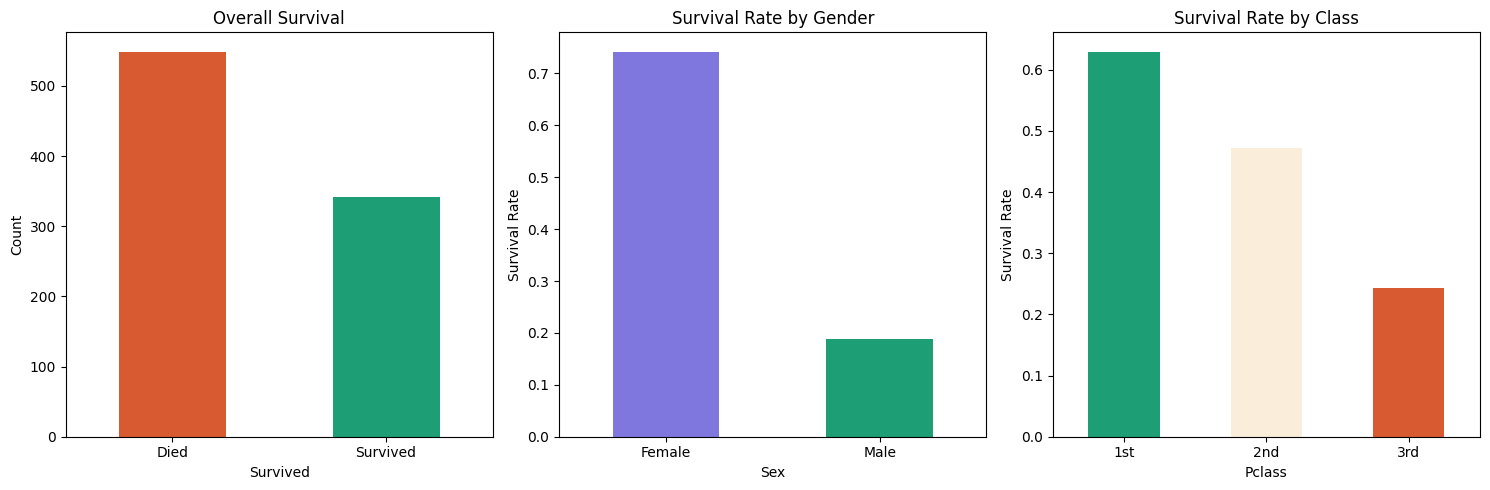

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# chart 1 — overall survival
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#D85A30','#1D9E75'])
axes[0].set_title('Overall Survival')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)
axes[0].set_ylabel('Count')

# chart 2 — survival by gender
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['#7F77DD','#1D9E75'])
axes[1].set_title('Survival Rate by Gender')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].set_ylabel('Survival Rate')

# chart 3 — survival by class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[2], color=['#1D9E75','#FAEEDA','#D85A30'])
axes[2].set_title('Survival Rate by Class')
axes[2].set_xticklabels(['1st','2nd','3rd'], rotation=0)
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.savefig('titanic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

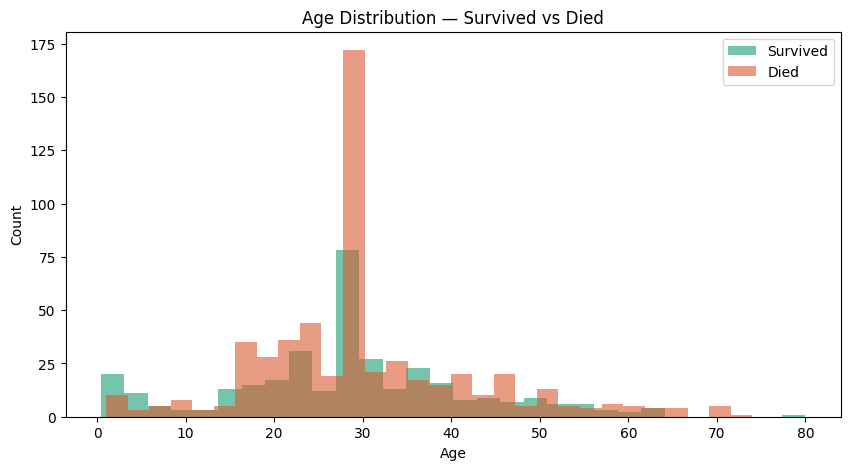

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

df[df['Survived'] == 1]['Age'].plot(kind='hist', bins=30, alpha=0.6, color='#1D9E75', label='Survived', ax=ax)
df[df['Survived'] == 0]['Age'].plot(kind='hist', bins=30, alpha=0.6, color='#D85A30', label='Died', ax=ax)

ax.set_title('Age Distribution — Survived vs Died')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=== TITANIC DATASET — KEY INSIGHTS ===")
print(f"\nTotal passengers: {len(df)}")
print(f"Overall survival rate: {round(df['Survived'].mean() * 100, 1)}%")
print(f"\nSurvival by gender:")
print(df.groupby('Sex')['Survived'].mean().round(2) * 100)
print(f"\nSurvival by class:")
print(df.groupby('Pclass')['Survived'].mean().round(2) * 100)
print(f"\nAverage age of survivors: {round(df[df['Survived']==1]['Age'].mean(), 1)}")
print(f"Average age of non-survivors: {round(df[df['Survived']==0]['Age'].mean(), 1)}")

=== TITANIC DATASET — KEY INSIGHTS ===

Total passengers: 891
Overall survival rate: 38.4%

Survival by gender:
Sex
female    74.0
male      19.0
Name: Survived, dtype: float64

Survival by class:
Pclass
1    63.0
2    47.0
3    24.0
Name: Survived, dtype: float64

Average age of survivors: 28.3
Average age of non-survivors: 30.0


In [12]:
survivors_30 = df[(df['Survived'] == 1) & (df['Age'].between(25, 35))]
print("Survivors aged 25-35 by gender:")
print(survivors_30['Sex'].value_counts())
print(f"\nFemale: {round(survivors_30[survivors_30['Sex']=='female'].shape[0] / len(survivors_30) * 100, 1)}%")
print(f"Male: {round(survivors_30[survivors_30['Sex']=='male'].shape[0] / len(survivors_30) * 100, 1)}%")

Survivors aged 25-35 by gender:
Sex
female    91
male      50
Name: count, dtype: int64

Female: 64.5%
Male: 35.5%
